# This notebook downloads, stores AORC data for given cites
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

#### Use culvert enviroemnt to run this script

In [57]:
# run it with culverts enviroments

In [5]:
# import libraries
import xarray as xr
#import fsspec
import numpy as np
#import s3fs
#import zarr
import pandas as pd
import matplotlib.pyplot as plt
#from tqdm import tqdm
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import datetime
import os
from matplotlib.dates import date2num
from matplotlib.lines import Line2D

In [ ]:
# Read the cities coordinates
cities=pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\us_cities_coordinates.csv")
cities

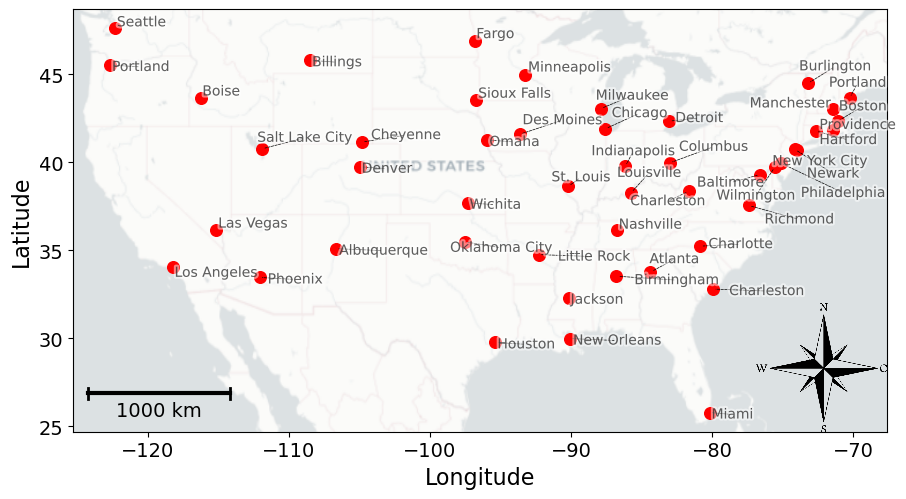

In [29]:
# run this with mapenv kernel
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.patheffects as pe
from adjustText import adjust_text
import pandas as pd
import numpy as np
from shapely.geometry import box
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import xyzservices.providers as xyz


# Your data
gdf = gpd.GeoDataFrame(
    cities,
    geometry=gpd.points_from_xy(cities.Longitude, cities.Latitude),
    crs="EPSG:4326"
)

gdf["CityShort"] = gdf["City"].str.split(",").str[0]

ratio = 3
fig, ax = plt.subplots(figsize=(3.5*ratio, 3.5*ratio))

# Plot points
gdf.plot(ax=ax, color="red", markersize=70)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326",
    alpha=0.8
)
if ax.texts:
    ax.texts[-1].set_visible(False)




# --- LABELS WITH adjustText ---
texts = []
for x, y, txt in zip(gdf.geometry.x, gdf.geometry.y, gdf["CityShort"]):
    texts.append(
        ax.text(
            x, y, txt,
            fontsize=10,
            ha="left",
            va="center",
            color="black",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")],
            zorder=4,
            alpha=0.5
        )
    )

adjust_text(
    texts,
    ax=ax,
    autoalign=True,
    expand_points=(1, 1),
    expand_text=(1, 1),
    arrowprops=dict(arrowstyle="-", linestyle="--", lw=0.5, color="black")
)

# --- FIX EXTENT ---
minx, miny, maxx, maxy = gdf.total_bounds
pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# ---------------------------------------------------------
# ------------------- FIXED SCALE BAR ---------------------
# ---------------------------------------------------------

bar_length_km = 1000   # your desired bar length

# Latitude of bar
lat_ref = miny + 0.05 * (maxy - miny)
lat_rad = np.deg2rad(lat_ref)

# meters per degree longitude here
meters_per_deg_lon = 111320 * np.cos(lat_rad)

# convert length to degrees
bar_length_deg = (bar_length_km * 1000) / meters_per_deg_lon

# --- POSITION: bottom-right ---
bar_x_start = minx - 0.03 * (maxx - minx)
bar_x_end = bar_x_start + bar_length_deg

bar_y = miny + 0.05 * (maxy - miny)

# Draw main bar
ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], color='black', lw=3)

# Tick size
tick_height = 0.3

# Draw ticks
ax.plot([bar_x_start, bar_x_start], [bar_y - tick_height, bar_y + tick_height], color='black', lw=2)
ax.plot([bar_x_end, bar_x_end], [bar_y - tick_height, bar_y + tick_height], color='black', lw=2)

# Label
ax.text(
    (bar_x_start + bar_x_end) / 2,
    bar_y - tick_height * 1.5,
    f"{bar_length_km} km",
    ha="center",
    va="top",
    fontsize=14,
    bbox=dict(facecolor="none", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"),
    zorder=10
)

# ---------------------------------------------------------
# ------------------- NORTH ARROW (optional) --------------
# ---------------------------------------------------------

north_img = mpimg.imread(r"D:\culvert repo\Results\north_arrow\N_arrow.png")
imagebox = OffsetImage(north_img, zoom=0.15)
ab = AnnotationBbox(imagebox, (0.92, 0.15), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

# ---------------------------------------------------------
# ------------------ AXES FORMATTING ----------------------
# ---------------------------------------------------------

ax.set_xlabel("Longitude", fontsize=16)
ax.set_ylabel("Latitude", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.savefig(r"D:\BMM-IDF4Drainage_data_results\Figure\AOI.png",
            dpi=300, bbox_inches='tight')
plt.show()


# Rain type

In [20]:
# --- inputs ---
fp_I   = r"D:\BMM-IDF4Drainage_data_results\Raintype\raintype_I.shp"
fp_IA  = r"D:\BMM-IDF4Drainage_data_results\Raintype\raintype_IA.shp"
fp_III = r"D:\BMM-IDF4Drainage_data_results\Raintype\raintype_III.shp"

# --- read cities -> GeoDataFrame (WGS84) ---
gdf_cities = gpd.GeoDataFrame(
    cities,
    geometry=gpd.points_from_xy(cities["Longitude"], cities["Latitude"]),
    crs="EPSG:4326"
)

# --- read polygons and reproject to cities CRS ---
gdf_I   = gpd.read_file(fp_I).to_crs(gdf_cities.crs)
gdf_IA  = gpd.read_file(fp_IA).to_crs(gdf_cities.crs)
gdf_III = gpd.read_file(fp_III).to_crs(gdf_cities.crs)

# --- initialize default ---
gdf_cities["rain_type"] = "II"

# helper: set rain_type for points that fall within polygon(s)
def assign_type(points_gdf, poly_gdf, label):
    hit = gpd.sjoin(
        points_gdf[["geometry"]].reset_index(),
        poly_gdf[["geometry"]],
        how="left",
        predicate="within"
    )
    idx_hit = hit.loc[hit["index_right"].notna(), "index"].values
    points_gdf.loc[idx_hit, "rain_type"] = label

# Priority order (later calls can overwrite earlier defaults)
assign_type(gdf_cities, gdf_I,   "I")
assign_type(gdf_cities, gdf_IA,  "IA")
assign_type(gdf_cities, gdf_III, "III")  # (you wrote 'IIII' but the type is usually 'III')

# back to normal DataFrame (drop geometry if you want)
cities_out = pd.DataFrame(gdf_cities.drop(columns="geometry"))
cities_out[['CityKey','rain_type']].to_csv(r"D:\BMM-IDF4Drainage_data_results\Raintype\raintype_cities.csv", index=False)


## pipe sizes as point colors

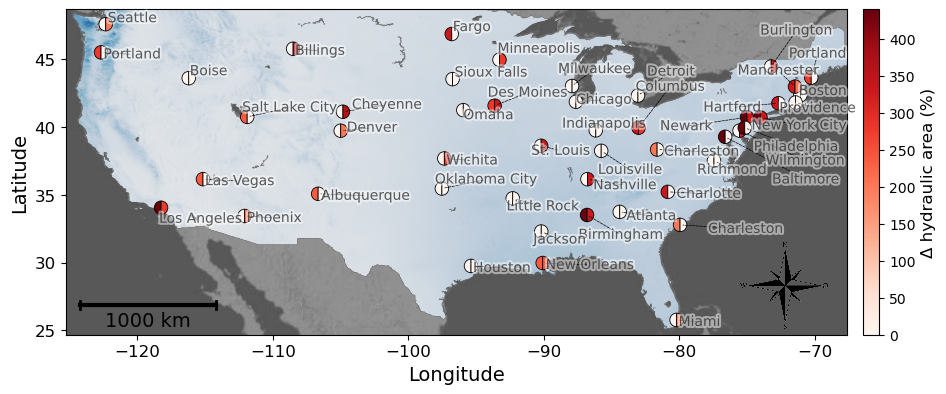

In [36]:
# run this with mapenv kernel
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.patheffects as pe
from adjustText import adjust_text
import pandas as pd
import numpy as np
from shapely.geometry import box
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import xyzservices.providers as xyz
from matplotlib.patches import Wedge
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import xarray as xr

# -------------------------------------------------------------------
# ------------------------ READ INPUT FILES -------------------------
# -------------------------------------------------------------------

# Cities file: must contain at least columns: 'City', 'Latitude', 'Longitude'
cities_fp    = r"D:\BMM-IDF4Drainage_data_results\us_cities_coordinates.csv"

aorc_24_fp   = r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv"
cmip6_24_fp  = r"D:\BMM-IDF4Drainage_data_results\Pipe size\CMIP6_24_hr.csv"
nc_fp = r"D:\BMM-IDF4Drainage_data_results\Data\USA Precipitation normals\prcp-1991_2020-monthly-normals-v1.0.nc"

cities       = pd.read_csv(cities_fp)
cities.loc[27,'Longitude']=-75## move newark a bit




df_24h       = pd.read_csv(aorc_24_fp)
df_24h_cmip6 = pd.read_csv(cmip6_24_fp)
cities['CityKey']       = cities['City'].str.split(',').str[0].str.strip()
df_24h['CityKey']       = df_24h['City'].str.split(',').str[0].str.strip()
df_24h_cmip6['CityKey'] = df_24h_cmip6['City'].str.split(',').str[0].str.strip()
# -------------------------------------------------------------------
# ------------------------ GEO DATAFRAME ----------------------------
# -------------------------------------------------------------------

gdf = gpd.GeoDataFrame(
    cities,
    geometry=gpd.points_from_xy(cities.Longitude, cities.Latitude),
    crs="EPSG:4326"
)
gdf["CityShort"] = gdf["CityKey"]   # or keep your old CityShort

# -------------------------------------------------------------------
# --------- PERCENT CHANGES (PIPE AREA) FOR THE TWO HALVES ----------
# -------------------------------------------------------------------
# 24h historical: Bayesian vs MLE
# 24h Bayesian: projected vs historical

df24_hist = df_24h[['CityKey', 'Bayesian', 'MLE']].copy()
df24_proj = df_24h_cmip6[['CityKey', 'Bayesian', 'MLE']].copy()

df24_hist = df24_hist.rename(columns={'Bayesian': 'Bayesian_hist',
                                      'MLE': 'MLE_hist'})
df24_proj = df24_proj.rename(columns={'Bayesian': 'Bayesian_proj',
                                      'MLE': 'MLE_proj'} )

df_merged = df24_hist.merge(df24_proj, on='CityKey', how='left')

# percent changes (same formulas)
df_merged['pct_B_vs_MLE_24h'] = np.where(
    df_merged['MLE_hist'] > 0,
    ((df_merged['Bayesian_hist']**2 - df_merged['MLE_hist']**2) /
     (df_merged['MLE_hist']**2))*10 * 100.0,
    np.nan
)

df_merged['pct_B_proj_vs_hist_24h'] = np.where(
    df_merged['Bayesian_hist'] > 0,
    ((df_merged['Bayesian_proj']**2 - df_merged['MLE_proj']**2) /
     (df_merged['MLE_proj']**2)) *10* 100.0,
    np.nan
)

# attach to gdf using CityKey
gdf = gdf.merge(
    df_merged[['CityKey', 'pct_B_vs_MLE_24h', 'pct_B_proj_vs_hist_24h']],
    on='CityKey',
    how='left'
)

# Diverging colormap centered at 0%
vals = pd.concat([
    gdf['pct_B_vs_MLE_24h'],
    gdf['pct_B_proj_vs_hist_24h']
]).astype(float)

vmax = np.nanmax(vals)
vmin = np.nanmin(vals)

if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0
if not np.isfinite(vmin):
    vmin = 0.0

# Simple linear normalization (no diverging center)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.Reds   

# -------------------------------------------------------------------
# --------------------------- FIGURE --------------------------------
# -------------------------------------------------------------------

ratio = 3
fig, ax = plt.subplots(figsize=(3.5*ratio, 6*ratio))

# Dummy plot to set extent (no visible markers)
gdf.plot(ax=ax, color="none", markersize=0)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief,
    crs="EPSG:4326",
    alpha=1
)
# Hide contextily attribution text
if ax.texts:
    ax.texts[-1].set_visible(False)

# -------------------------------------------------------------------
# ------------- PRECIPITATION NORMALS RASTER OVERLAY ----------------
# -------------------------------------------------------------------

ds = xr.open_dataset(nc_fp)

# change 'mlyprcp_norm' and 'time' if your variable / dimension names differ
da = ds['mlyprcp_norm']

# Example: mean over time dimension to get a single 2D field
da_plot = da.mean('time')

# Ensure lats/lons are increasing for imshow
da_plot = da_plot.sortby('lat').sortby('lon')

lons = da_plot['lon'].values
lats = da_plot['lat'].values

# Use whole grid extent (in degrees)
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Plot on top of the basemap, but below the city markers
ax.imshow(
    da_plot.values,
    extent=extent,
    origin='lower',
    cmap='Blues',   # similar to your example map
    alpha=0.8,       # requested transparency
    zorder=1         # below half-circle markers (which use zorder=3)
)


# -------------------------------------------------------------------
# ---- CUSTOM HALF-CIRCLE MARKERS (INSTEAD OF RED POINTS) ----------
# -------------------------------------------------------------------
# Left half  : 24-h Bayesian vs 24-h MLE (historical)
# Right half : 24-h Bayesian projected vs 24-h Bayesian historical

marker_radius = 0.5  # in degrees – tune if needed

for _, row in gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y

    v_left = row['pct_B_vs_MLE_24h']
    v_right = row['pct_B_proj_vs_hist_24h']

    # Colors from colormap, gray if missing
    if pd.notna(v_left):
        color_left = cmap(norm(float(v_left)))
    else:
        color_left = (0.8, 0.8, 0.8, 1.0)

    if pd.notna(v_right):
        color_right = cmap(norm(float(v_right)))
    else:
        color_right = (0.8, 0.8, 0.8, 1.0)

    # Left half (west side)
    wedge_left = Wedge(
        (x, y),
        marker_radius,
        theta1=90,   # north→south (left)
        theta2=270,
        facecolor=color_left,
        edgecolor='black',
        lw=0.6,
        zorder=3
    )

    # Right half (east side)
    wedge_right = Wedge(
        (x, y),
        marker_radius,
        theta1=-90,  # south→north (right)
        theta2=90,
        facecolor=color_right,
        edgecolor='black',
        lw=0.6,
        zorder=3
    )

    ax.add_patch(wedge_left)
    ax.add_patch(wedge_right)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02,shrink=0.5)
cbar.set_label("Δ hydraulic area (%)", fontsize=12)

# Small note explaining halves
#ax.text(
#    0.28, 0.02,
#    "Left: Bayesian vs MLE (historical period)\nRight: Bayesian vs MLE (projected period)",
#    transform=ax.transAxes,
#    fontsize=12,
#    va="bottom", ha="left",
#    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
#)


# -------------------------------------------------------------------
# --- LABELS WITH adjustText (kept from your original code) ---------
# -------------------------------------------------------------------

texts = []
for x, y, txt in zip(gdf.geometry.x, gdf.geometry.y, gdf["CityShort"]):
    texts.append(
        ax.text(
            x, y, txt,
            fontsize=10,
            ha="left",
            va="center",
            color="black",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")],
            zorder=4,
            alpha=0.5
        )
    )

adjust_text(
    texts,
    ax=ax,
    autoalign=True,
    expand_points=(3, 3),
    expand_text=(3, 3),
    arrowprops=dict(arrowstyle="-", linestyle="--", lw=0.5, color="black")
)

# -------------------------------------------------------------------
# ----------------------- FIX EXTENT --------------------------------
# -------------------------------------------------------------------

minx, miny, maxx, maxy = gdf.total_bounds
pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# -------------------------------------------------------------------
# ---------------------- FIXED SCALE BAR ----------------------------
# -------------------------------------------------------------------

bar_length_km = 1000   # desired bar length

lat_ref = miny + 0.06 * (maxy - miny)
lat_rad = np.deg2rad(lat_ref)
meters_per_deg_lon = 111320 * np.cos(lat_rad)
bar_length_deg = (bar_length_km * 1000) / meters_per_deg_lon

# position approximate bottom-right
bar_x_start = minx - 0.03 * (maxx - minx)
bar_x_end   = bar_x_start + bar_length_deg
bar_y       = miny + 0.05 * (maxy - miny)

ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y], color='black', lw=3)

tick_height = 0.3
ax.plot([bar_x_start, bar_x_start],
        [bar_y - tick_height, bar_y + tick_height],
        color='black', lw=2)
ax.plot([bar_x_end, bar_x_end],
        [bar_y - tick_height, bar_y + tick_height],
        color='black', lw=2)

ax.text(
    (bar_x_start + bar_x_end) / 2,
    bar_y - tick_height * 1.5,
    f"{bar_length_km} km",
    ha="center",
    va="top",
    fontsize=14,
    bbox=dict(facecolor="none", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"),
    zorder=10
)

# -------------------------------------------------------------------
# ------------------- NORTH ARROW (optional) ------------------------
# -------------------------------------------------------------------

north_img = mpimg.imread(r"D:\culvert repo\Results\north_arrow\N_arrow.png")
imagebox = OffsetImage(north_img, zoom=0.10)
ab = AnnotationBbox(imagebox, (0.92, 0.15), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

# -------------------------------------------------------------------
# ---------------------- AXES FORMATTING ----------------------------
# -------------------------------------------------------------------

ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.savefig(r"D:\BMM-IDF4Drainage_data_results\Figure\AOI_half_circles.png",
            dpi=300, bbox_inches='tight')
plt.show()


In [27]:
df_merged

,CityKey,Bayesian_hist,MLE_hist,Bayesian_proj,MLE_proj,pct_B_vs_MLE_24h,pct_B_proj_vs_hist_24h
0,Birmingham,1800,1500,1500,1300,440.0,331.360947
1,Phoenix,1050,1050,1150,1050,0.0,199.546485
2,Little Rock,1800,1800,2000,2000,0.0,0.000000
3,Los Angeles,1800,1500,1300,1150,440.0,277.882798
4,Denver,1050,1050,1150,1050,0.0,199.546485
...,...,...,...,...,...,...,...
167,Burlington,1300,1300,1500,1300,0.0,331.360947
168,Richmond,1500,1500,1500,1500,0.0,0.000000
169,Seattle,1500,1500,1150,1050,0.0,199.546485
170,Milwaukee,1300,1300,1050,1050,0.0,0.000000


In [15]:
def aorc_hourly_daily_timeseries_maxima_plots(
    lat,
    lon,
    city,
    start_year = None,
    end_year=2024,
):
    """
    Downloads hourly AORC precipitation at the nearest grid point to (lat, lon),
    computes calendar-day totals, plots both with annual maxima markers,
    and saves the figure + CSVs (hourly, daily, and their annual maxima).
    """
    output_dir=rf"D:\BMM-IDF4Drainage_data_results\Data\AORC\{city}"
    os.makedirs(output_dir, exist_ok=True)
   
   # select the start_year based on `city`
    if start_year is None:
        start_year = 1981 if city == 'Anchorage, Alaska' else 1979
    

    base_url = "s3://noaa-nws-aorc-v1-1-1km"
    var = "APCP_surface"
    years = range(start_year, end_year + 1)

    # ---- Load hourly series across years ----
    all_ts = []
    for year in tqdm(years, desc="Loading years"):
        url = f"{base_url}/{year}.zarr/"
        ds = xr.open_zarr(url, consolidated=True, storage_options={"anon": True})
        precip_ts = ds[var].sel(latitude=lat, longitude=lon, method="nearest")
        s = precip_ts.to_series()
        s.index = pd.to_datetime(s.index)
        all_ts.append(s)

    hourly_series = pd.concat(all_ts).sort_index()

    # ---- Daily totals (calendar day) ----
    daily_totals = hourly_series.resample("D").sum()

    # ---- Annual maxima (hourly) ----
    # index (timestamp) of the max hourly observation per year
    hr_idxmax = hourly_series.resample("YE").apply(lambda x: x.idxmax()).dropna()
    hr_annual_max = hourly_series.loc[hr_idxmax].dropna()
    #  table for export
    hr_annual_max_df = pd.DataFrame({
        "max_datetime": hr_annual_max.index,
        "max_hourly_mm": hr_annual_max.values
    })
    hr_annual_max_df.index = hr_annual_max.index.year
    hr_annual_max_df.index.name = "year"

    # ---- Annual maxima (daily totals) ----
    dy_idxmax = daily_totals.resample("YE").apply(lambda x: x.idxmax()).dropna()
    dy_annual_max = daily_totals.loc[dy_idxmax].dropna()
    dy_annual_max_df = pd.DataFrame({
        "max_date": dy_annual_max.index.date,
        "max_daily_mm": dy_annual_max.values
    })
    dy_annual_max_df.index = dy_annual_max.index.year
    dy_annual_max_df.index.name = "year"

    # ---- Plot: Hourly + Daily; mark both sets of annual maxima ----
    fig, ax = plt.subplots(figsize=(10, 5))
    hourly_series.plot(ax=ax, label="Hourly Precipitation (mm)", linewidth=0.8, alpha=0.5)

    ax2 = ax.twinx()
    daily_totals.plot(
        ax=ax2, label="Daily Precipitation (mm)",
        linewidth=0.8, alpha=0.5, color="black"
    )

    # Mark hourly annual maxima (left axis)
    ax.scatter(
        hr_annual_max.index,
        hr_annual_max.values,
        marker="*",
        s=120,
        facecolors="white",
        edgecolors="red",
        linewidths=1.2,
        label="Annual Maxima (hourly)",
        zorder=5
    )

    # Mark daily annual maxima (right axis)
    ax2.scatter(
        dy_annual_max.index,
        dy_annual_max.values,
        marker="^",
        s=50,
        facecolors="white",
        edgecolors="red",
        linewidths=1.0,
        label="Annual Maxima (daily)",
        zorder=6
    )

    # Axis formatting
    ax.set_ylabel("Hourly precipitation (mm)")
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", alpha=0.6)

    ax2.set_ylabel("Daily precipitation (mm)")
    ax2.set_ylim(bottom=0)

    # Combine legends
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(
        h1 + h2,
        l1 + l2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        frameon=False,
    )

    plt.title(f"{city}", fontsize=13)
    plt.tight_layout()

    # ---- Save figure (and also show) ----
    fig_path = os.path.join(output_dir, f"{city}_precip_timeseries.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show() 
    plt.close(fig)

    # ---- Save data ----
    hourly_path = os.path.join(output_dir, f"{city}_hourly.csv")
    daily_path  = os.path.join(output_dir, f"{city}_daily.csv")
    hr_max_path = os.path.join(output_dir, f"{city}_annual_max_hourly.csv")
    dy_max_path = os.path.join(output_dir, f"{city}_annual_max_daily.csv")

    hourly_series.rename("precip_mm").to_csv(hourly_path, header=True)
    daily_totals.rename("precip_daily_mm").to_csv(daily_path, header=True)
    hr_annual_max_df.to_csv(hr_max_path)
    dy_annual_max_df.to_csv(dy_max_path)

    return {
        "figure": fig_path,
        "hourly_csv": hourly_path,
        "daily_csv": daily_path,
        "annual_max_hourly_csv": hr_max_path,
        "annual_max_daily_csv": dy_max_path,
    }


# Example

Loading years: 100%|██████████| 46/46 [01:04<00:00,  1.41s/it]


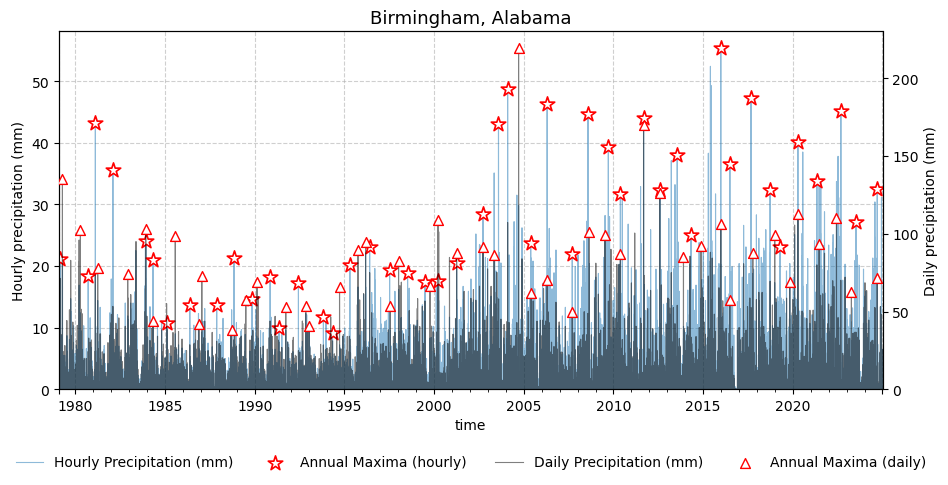

{'figure': 'D:\\BMM-IDF4Drainage_data_results\\Data\\AORC\\Birmingham, Alabama\\Birmingham, Alabama_precip_timeseries.png',
 'hourly_csv': 'D:\\BMM-IDF4Drainage_data_results\\Data\\AORC\\Birmingham, Alabama\\Birmingham, Alabama_hourly.csv',
 'daily_csv': 'D:\\BMM-IDF4Drainage_data_results\\Data\\AORC\\Birmingham, Alabama\\Birmingham, Alabama_daily.csv',
 'annual_max_hourly_csv': 'D:\\BMM-IDF4Drainage_data_results\\Data\\AORC\\Birmingham, Alabama\\Birmingham, Alabama_annual_max_hourly.csv',
 'annual_max_daily_csv': 'D:\\BMM-IDF4Drainage_data_results\\Data\\AORC\\Birmingham, Alabama\\Birmingham, Alabama_annual_max_daily.csv'}

In [16]:
aorc_hourly_daily_timeseries_maxima_plots(cities["Latitude"][0], cities["Longitude"][0],cities["City"][0])

## Plot for schematic

In [ ]:
fig, ax = plt.subplots(figsize=(1.5, 1))

# Base line plot
ts_line = ax.plot(hourly_rain.time.values,
                  hourly_rain['precip_mm'].values,
                  linewidth=0.1, alpha=0.5, color="steelblue",
                  label="Time Series")

# Scatter on top
ts_max = ax.scatter(max_hourly_rain.max_datetime.values,
                    max_hourly_rain['max_hourly_mm'].values,
                    marker="*",
                    s=1,
                    facecolors="white",
                    edgecolors="red",
                    alpha=0.7,
                    label="Annual Maxima")

# Axis formatting
ax.set_ylabel("Rainfall", labelpad=1)
ax.set_xlabel("Time", labelpad=2)
ax.set_ylim(bottom=0)

ax.set_xticks([])
ax.set_yticks([])

ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

# --- Add legend (2 columns, top-right) ---
# Create custom handles ONLY for the legend
legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=1.5, label="Time Series"),
    Line2D([0], [0], marker="*", color="red", markersize=6,
           linestyle="None", label="Annual Maxima")
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    ncol=1,
    frameon=False,
    fontsize=6,
    handlelength=2.5,
    handletextpad=0.4
)
plt.tight_layout(pad=200)
plt.show()
fig.savefig(r'D:\repos\BMM-IDF4Drainage-paper\Figures\jpeg\data figures\hist_timeseries.png',
            dpi=300,
            bbox_inches="tight")
plt.close(fig)

# Iterate over all cities


In [ ]:
for _, row in cities.iterrows():
    print(row["City"], row["Latitude"], row["Longitude"]) 
    aorc_hourly_daily_timeseries_maxima_plots(row["Latitude"], row["Longitude"],row["City"])


In [63]:
# Date and time
now = datetime.datetime.now()
print(f"Date and time: {now}")

Date and time: 2025-09-30 15:08:34.348878


In [1]:
%load_ext watermark
# Print the Python version and some dependencies
%watermark -v -m -p numpy,pandas,geopandas,matplotlib,os,rasterio,tqdm,contextily,shapely,planetary_computer,pystac_client,dask

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.20.0

numpy             : 2.0.2
pandas            : 2.2.2
geopandas         : 1.0.1
matplotlib        : 3.8.4
os                : unknown
rasterio          : 1.4.3
tqdm              : 4.66.5
contextily        : 1.6.1
shapely           : 2.0.7
planetary_computer: 1.0.0
pystac_client     : 0.8.3
xclim             : 0.56.0
dask              : 2024.8.1

Compiler    : MSC v.1940 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 24
Architecture: 64bit

